# MFAA Chapter 4 Laboratory
**Stochastic DCF Engine** (book §4.9)

The book's first full valuation engine: LDCF operator of Theorem 4.8, premium location, regimes, Bayesian parameter uncertainty. Designed as a **hurdle-rate autopsy**. Seed `20260400`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch04
from dataclasses import replace

## 1. E1 — Hurdle autopsy
Enter a flat 12% and see what the point estimate was hiding.

In [2]:
p = ch04.DCFParams()
au = ch04.hurdle_autopsy(p)
print(f"flat 12% deterministic value: {au['flat_value']:.4f}")
print(f"full-model mean: {au['full']['mean']:.4f} ± {au['full']['se']:.4f}")
print(f"implied honest flat rate: {au['implied']['implied_flat_rate']:.4f}")
import pandas as pd
pd.DataFrame(au['decomposition'])

flat 12% deterministic value: 0.9554
full-model mean: 1.1504 ± 0.0028
implied honest flat rate: 0.0758


,stage,mean,se,std,quantiles
0,deterministic DCF,1.403467,1.570132e-18,2.220502e-16,"{'q05': 1.4034674333159036, 'q25': 1.403467433..."
1,+ rate risk,1.247307,1.684262e-03,2.381906e-01,"{'q05': 0.8632866286499349, 'q25': 1.046989656..."
2,+ price-of-risk wedges,1.154518,2.512370e-03,3.553028e-01,"{'q05': 0.7591024275595836, 'q25': 0.900515645..."
3,+ liquidity friction/factor,1.150428,2.840822e-03,4.017529e-01,"{'q05': 0.7194574347974299, 'q25': 0.875777502..."


## 2. The valuation distribution the hurdle was hiding

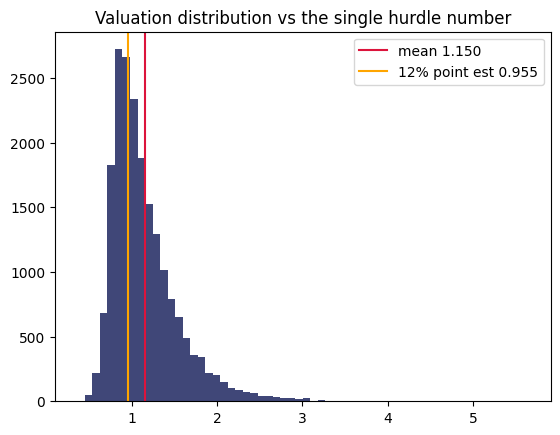

In [3]:
from engine.ch04 import _simulate_value
v = _simulate_value(p, 'full')
plt.hist(v, bins=60, color='#1E2761', alpha=.85)
plt.axvline(v.mean(), color='crimson', label=f'mean {v.mean():.3f}')
plt.axvline(au['flat_value'], color='orange', label=f"12% point est {au['flat_value']:.3f}")
plt.legend(); plt.title('Valuation distribution vs the single hurdle number');

## 3. E2 — Double-count demonstration
The single most opinion-changing exercise in Part II: value illiquidity once as a factor in M, once as a friction in the operator, then force both on.

In [4]:
dc = ch04.double_count_check(p)
print(f"factor-in-M:        {dc['factor_in_M']['mean']:.4f}")
print(f"friction-in-operator: {dc['friction_in_operator']['mean']:.4f}")
print(f"both active (bug):   {dc['both_active']['mean']:.4f}")
print(f"double-count bias:   {dc['double_count_bias_vs_factor']:.4f}")

factor-in-M:        1.1504
friction-in-operator: 1.1324
both active (bug):   1.1324
double-count bias:   -0.0180


## 4. E4 — Learning curve (Bayesian panel, Proposition 4.7)
Feed deal outcomes one at a time; watch the posterior premium spread shrink.

In [5]:
bu = ch04.bayesian_update(0.03, 0.02, 0.05, [0.05,0.01,0.04,0.02,0.06,0.03,0.045])
for n,(mn,sd) in enumerate(zip(bu['posterior_mean'], bu['posterior_sd']),1):
    print(f"n={n}: posterior {mn:.4f} ± {sd:.4f}")
print('recursion matches batch:', bu['recursion_matches_batch'])

n=1: posterior 0.0328 ± 0.0186
n=2: posterior 0.0300 ± 0.0174
n=3: posterior 0.0311 ± 0.0164
n=4: posterior 0.0300 ± 0.0156
n=5: posterior 0.0327 ± 0.0149
n=6: posterior 0.0324 ± 0.0143
n=7: posterior 0.0334 ± 0.0137
recursion matches batch: True


## 5. Zero-coupon curve (closed form vs Monte Carlo) and validation

In [6]:
mats=[1,2,3,5,7,10]
cf=ch04.zcb_closed_form(p,mats); mc=ch04.zcb_monte_carlo(replace(p,M=40000),mats)
for i,T in enumerate(mats): print(f"T={T:2d}  closed {cf[i]:.5f}  MC {mc['price'][i]:.5f} ± {mc['se'][i]:.5f}")
v = ch04.validation_checks()
print('\nvalidation ALL:', v['all_pass'])

T= 1  closed 0.96947  MC 0.96941 ± 0.00003
T= 2  closed 0.93841  MC 0.93826 ± 0.00007
T= 3  closed 0.90738  MC 0.90714 ± 0.00011
T= 5  closed 0.84674  MC 0.84653 ± 0.00019
T= 7  closed 0.78902  MC 0.78877 ± 0.00024
T=10  closed 0.70890  MC 0.70868 ± 0.00030



validation ALL: True
